# **Similarity Search**

**Loading data**

In [3]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("gpiosenka/butterfly-images40-species")

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'butterfly-images40-species' dataset.
Path to dataset files: /kaggle/input/butterfly-images40-species


In [4]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.load('/content/embeddings.npy')
y = np.load('/content/labels.npy')

print(f"Dataset Shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Dataset Shape: (12594, 2048)


In [5]:
import glob
import os


#Get all image paths in the exact same alphabetical order as DataLoader we used while embeddings extraction
search_path = os.path.join(dataset_path, 'train', '**', '*.jpg')
all_image_paths = sorted(glob.glob(search_path, recursive=True))

print(f"Found {len(all_image_paths)} images.")

paths_train, paths_test, _, _ = train_test_split(
    all_image_paths,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training paths aligned: {len(paths_train)}")
print(f"Testing paths aligned: {len(paths_test)}")

Found 12594 images.
Training paths aligned: 10075
Testing paths aligned: 2519


### **Brute-Force Search Function**

In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_bugs (query_embedding, bug_embeddings, bug_ids, top_n=5):
  q_reshaped = query_embedding.reshape(1,-1)
  similarities= cosine_similarity(q_reshaped, bug_embeddings)[0]
  best_ids= np.argsort(similarities)[-top_n:][::-1]

  print('Top 5 visual matches')
  for rank, idx in enumerate(best_ids):
    score= similarities[idx]
    label= bug_ids[idx]

    if score > 0.999:
            print(f"{rank + 1}. Class {label} | Similarity: {score:.4f} (Identical Image)")
    else:
            print(f"{rank + 1}. Class {label} | Similarity: {score:.4f}")

  return best_ids

**testing...**

In [7]:
test_bug = X_test[0]
test_bug_id = y_test[0]

print(f"Query Image is actually Class: {test_bug_id}\n")
similar_bugs = find_similar_bugs(test_bug, X_train, y_train)

Query Image is actually Class: 44

Top 5 visual matches
1. Class 44 | Similarity: 0.8568
2. Class 44 | Similarity: 0.8461
3. Class 86 | Similarity: 0.8453
4. Class 86 | Similarity: 0.8423
5. Class 86 | Similarity: 0.8423


In [8]:
test_bug = X_test[110]
test_bug_id = y_test[110]

print(f"Query Image is actually Class: {test_bug_id}\n")
similar_bugs = find_similar_bugs(test_bug, X_train, y_train)

Query Image is actually Class: 59

Top 5 visual matches
1. Class 59 | Similarity: 0.9210
2. Class 59 | Similarity: 0.9085
3. Class 70 | Similarity: 0.8942
4. Class 59 | Similarity: 0.8937
5. Class 70 | Similarity: 0.8918


In [9]:
test_bug = X_test[569]
test_bug_id = y_test[569]

print(f"Query Image is actually Class: {test_bug_id}\n")
similar_bugs = find_similar_bugs(test_bug, X_train, y_train)

Query Image is actually Class: 30

Top 5 visual matches
1. Class 30 | Similarity: 0.8524
2. Class 77 | Similarity: 0.8422
3. Class 61 | Similarity: 0.8408
4. Class 32 | Similarity: 0.8388
5. Class 2 | Similarity: 0.8375


**Visual testing...**

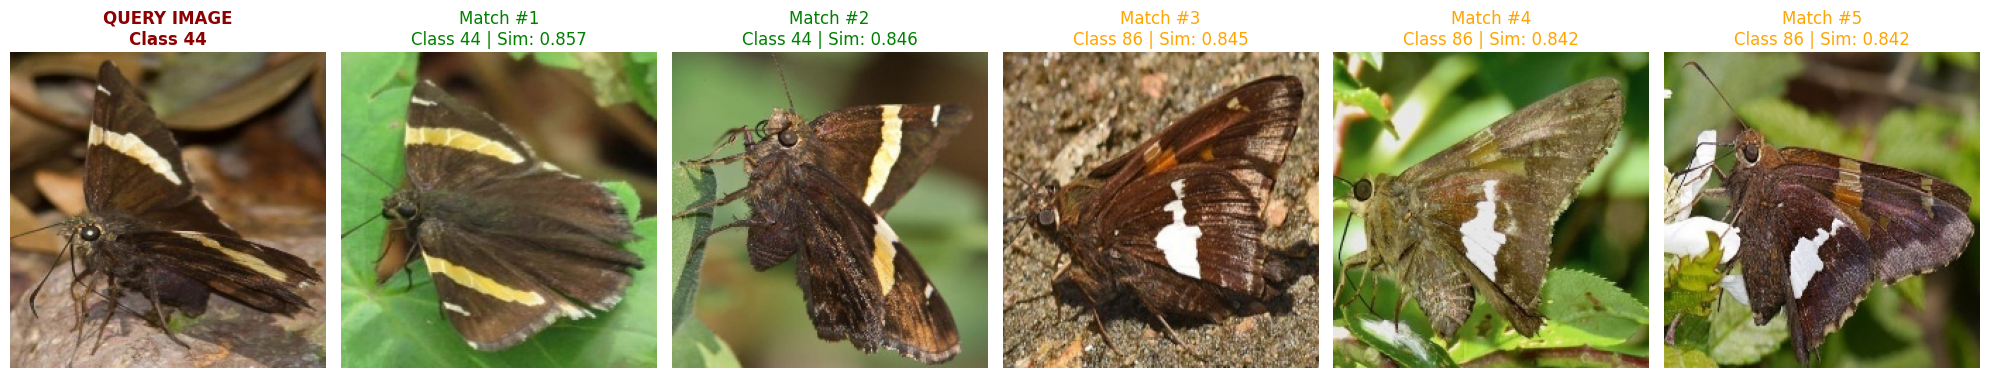

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

def visual_search(query_idx, top_n=5):
    query_vec = X_test[query_idx].reshape(1, -1)
    similarities = cosine_similarity(query_vec, X_train)[0]

    #Sort and get top N matches
    best_indices = np.argsort(similarities)[-top_n:][::-1]

    #Setup plot grid (1 row: Query on far left, then Top Matches)
    fig, axes = plt.subplots(1, top_n + 1, figsize=(20, 4))

    #Plot the Query Image
    query_img_path = paths_test[query_idx]
    query_img = Image.open(query_img_path)

    axes[0].imshow(query_img)
    axes[0].set_title(f"QUERY IMAGE\nClass {y_test[query_idx]}", color='darkred', fontweight='bold')
    axes[0].axis('off')

    #Plot the Matches
    for i, idx in enumerate(best_indices):
        score = similarities[idx]
        match_label = y_train[idx]
        match_img_path = paths_train[idx]

        match_img = Image.open(match_img_path)
        axes[i+1].imshow(match_img)

        title_color = 'green' if match_label == y_test[query_idx] else 'orange'

        axes[i+1].set_title(f"Match #{i+1}\nClass {match_label} | Sim: {score:.3f}", color=title_color)
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

visual_search(query_idx=0, top_n=5)

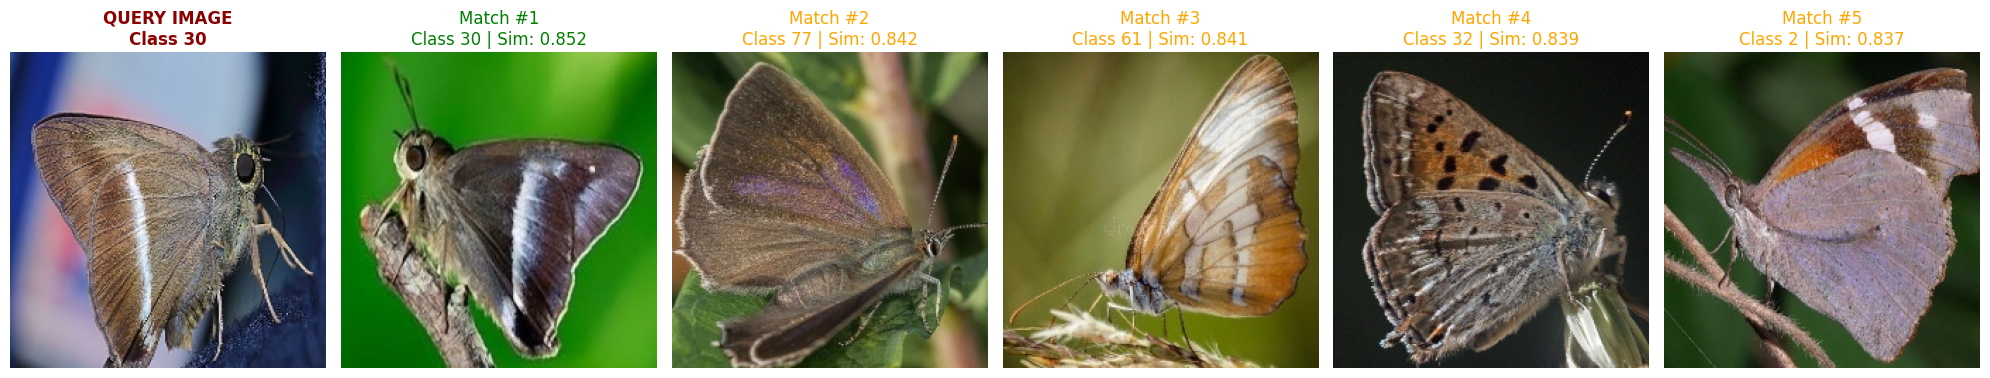

In [11]:
#testing on different image
visual_search(query_idx=569)

# **UnSupervised Clustering Using UMAP**

In [12]:
!pip install umap-learn

Running UMAP to map 2048D down to 2D...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting the Universe...


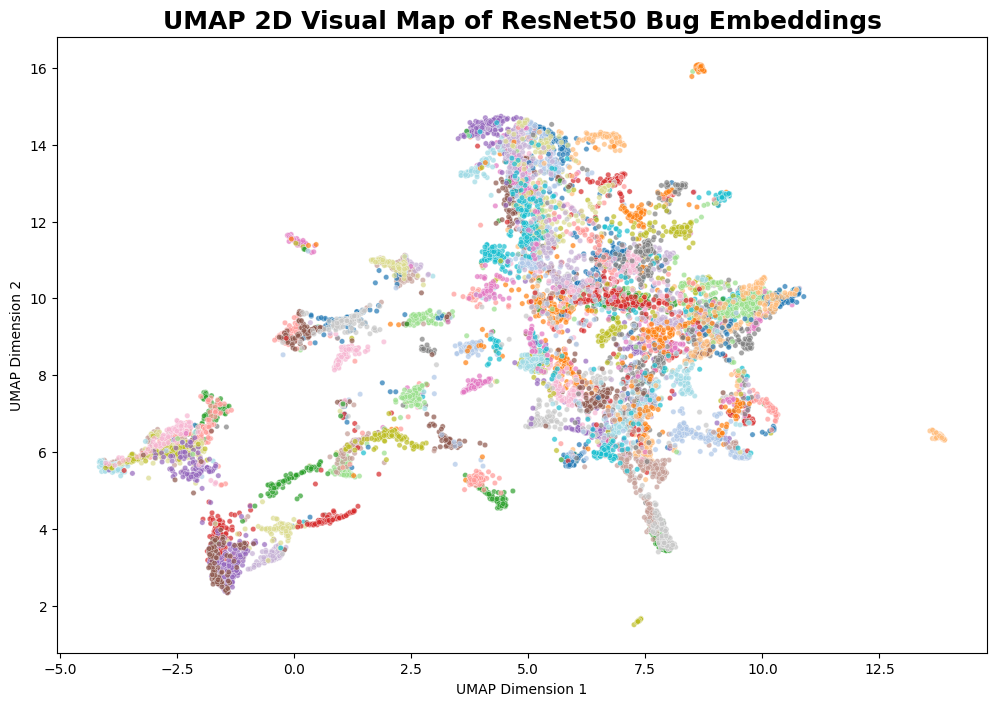

In [13]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("Running UMAP to map 2048D down to 2D...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)

X_umap = reducer.fit_transform(X)

umap_df = pd.DataFrame({
    'UMAP_1': X_umap[:, 0],
    'UMAP_2': X_umap[:, 1],
    'Class': y
})

print("Plotting the Universe...")
plt.figure(figsize=(12, 8))

# Scatterplot colored by species (Class)
sns.scatterplot(
    x='UMAP_1', y='UMAP_2',
    hue='Class',
    palette='tab20',
    data=umap_df,
    legend=False,
    alpha=0.7,
    s=15
)

plt.title("UMAP 2D Visual Map of ResNet50 Bug Embeddings", fontsize=18, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

## **K-Means on our Embeddings**

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=40, random_state=42, n_init='auto')

unsupervised_clusters = kmeans.fit_predict(X)

3. Plotting the Unsupervised Clusters...


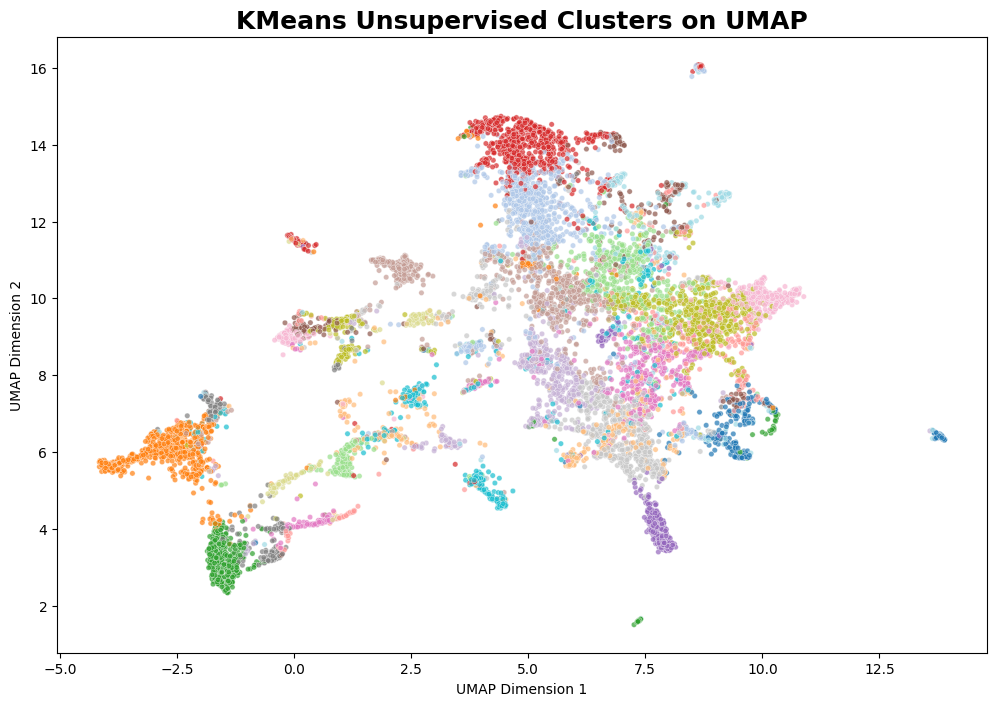

In [15]:
umap_df['KMeans_Cluster'] = unsupervised_clusters

print("3. Plotting the Unsupervised Clusters...")
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='UMAP_1', y='UMAP_2',
    hue='KMeans_Cluster',
    palette='tab20',
    data=umap_df,
    legend=False,
    alpha=0.7,
    s=15
)

plt.title("KMeans Unsupervised Clusters on UMAP", fontsize=18, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

### **Unsupervised Clustering (KMeans) Conclusion**
To test if our embeddings naturally separated into species without human labels, we ran a KMeans clustering algorithm (k=40) on the raw 2048-dimensional data and plotted the resulting assignments onto our UMAP coordinates.

**Observations:**
The KMeans clusters do *not* perfectly map to the true biological species. While some isolated islands align well, the dense central clusters show that KMeans created solid "visual territories" out of areas where multiple species originally overlapped.

**Verdict:**
ResNet50 is grouping images based on visual archetypes (e.g., shared color palettes, wing patterns, or background foliage) rather than pure biological taxonomy. This explains our supervised classification ceiling of 88.6%: to a general-purpose vision model, several distinct species are mathematically indistinguishable based on visual features alone.

**saving umap_df as csv....**

In [16]:
umap_df.to_csv('umap_df.csv', index=False)